In [3]:
import pandas as pd

braces_area = '/Users/matthewng/Downloads/area.xlsx'
braces_area_df = pd.read_excel(braces_area)

In [45]:
from sklearn.model_selection import train_test_split

# Create a derived feature: percentage of detected area
braces_area_df["Percentage of Detected Area"] = (braces_area_df["Brace area"] / braces_area_df["Total area"]) * 100

print(braces_area_df.head())

X = braces_area_df[['Brace area', 'Percentage of Detected Area']].values
y = braces_area_df['Is case?'].values

# Perform stratified train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
                                                    stratify=y, random_state=42)
print("Cell 3: Train-test split completed!")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

      Unnamed: 0  Brace area  Total area  Is case?  \
0  710874_PX.png         120      645120         1   
1  968861_PX.png         549      645120         1   
2  558948_PX.png        3198      645120         1   
3  780437_PX.png           0      645120         1   
4  657988_PX.png        1415      645120         1   

   Percentage of Detected Area  
0                     0.018601  
1                     0.085100  
2                     0.495722  
3                     0.000000  
4                     0.219339  
Cell 3: Train-test split completed!
Training set shape: (375, 2)
Test set shape: (125, 2)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

In [46]:
lr_model = LogisticRegression(C=10, penalty='l1', solver='saga', class_weight='balanced')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred_lr)
report = classification_report(y_test, y_pred_lr)

train_accuracy = lr_model.score(X_train_scaled, y_train)
test_accuracy = lr_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

train_pred = lr_model.predict(X_train_scaled)
test_pred = lr_model.predict(X_test_scaled)

cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Testing Classification Report:")
print(classification_report(y_test, test_pred))


print("Training Classification Report:")
print(classification_report(y_train, train_pred))



Training Accuracy: 0.8453
Testing Accuracy: 0.9120
Cross-validation Accuracy: 0.8427 ± 0.0390
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        64
           1       1.00      0.82      0.90        61

    accuracy                           0.91       125
   macro avg       0.93      0.91      0.91       125
weighted avg       0.92      0.91      0.91       125

Training Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.97      0.86       186
           1       0.96      0.72      0.82       189

    accuracy                           0.85       375
   macro avg       0.87      0.85      0.84       375
weighted avg       0.87      0.85      0.84       375



Decision Tree Model


In [14]:
from sklearn.tree import DecisionTreeClassifier

# Train a Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=None, min_samples_split=10, min_samples_leaf=4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
dt_model.fit(X_train_scaled, y_train)


# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test_scaled)
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the Decision Tree model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

train_accuracy = dt_model.score(X_train_scaled, y_train)
test_accuracy = dt_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

train_pred = dt_model.predict(X_train_scaled)
test_pred = dt_model.predict(X_test_scaled)

cv_scores = cross_val_score(dt_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Testing Classification Report:")
print(classification_report(y_test, test_pred))

print("Training Classification Report:")
print(classification_report(y_train, train_pred))



Training Accuracy: 0.8907
Testing Accuracy: 0.9200
Cross-validation Accuracy: 0.8747 ± 0.0107
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        64
           1       0.96      0.87      0.91        61

    accuracy                           0.92       125
   macro avg       0.92      0.92      0.92       125
weighted avg       0.92      0.92      0.92       125

Training Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       186
           1       0.96      0.82      0.88       189

    accuracy                           0.89       375
   macro avg       0.90      0.89      0.89       375
weighted avg       0.90      0.89      0.89       375



In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=2, min_samples_split=10, bootstrap=False, random_state=42, class_weight='balanced')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
rf_model.fit(X_train_scaled, y_train)


# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

train_accuracy = rf_model.score(X_train_scaled, y_train)
test_accuracy = rf_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

train_pred = rf_model.predict(X_train_scaled)
test_pred = rf_model.predict(X_test_scaled)

cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Testing Classification Report:")
print(classification_report(y_test, test_pred))

print("Training Classification Report:")
print(classification_report(y_train, train_pred))

Training Accuracy: 0.8960
Testing Accuracy: 0.9040
Cross-validation Accuracy: 0.8720 ± 0.0136
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        64
           1       0.96      0.84      0.89        61

    accuracy                           0.90       125
   macro avg       0.91      0.90      0.90       125
weighted avg       0.91      0.90      0.90       125

Training Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       186
           1       0.96      0.83      0.89       189

    accuracy                           0.90       375
   macro avg       0.90      0.90      0.90       375
weighted avg       0.90      0.90      0.90       375



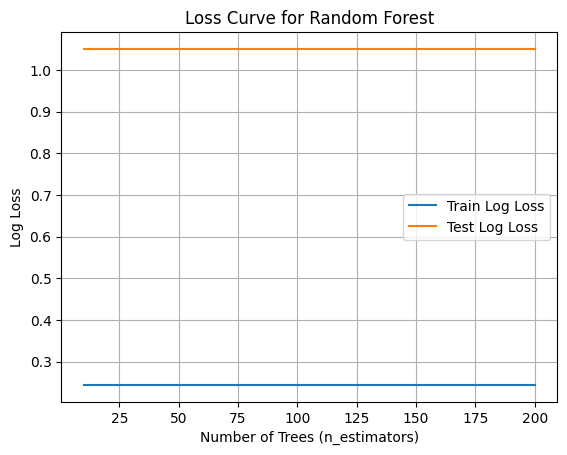

In [152]:
train_losses = []
test_losses = []
n_estimators_range = range(10, 201, 10)  # Trees from 10 to 200

for n in n_estimators_range:
    model = RandomForestClassifier(
        n_estimators=n, max_depth=10, min_samples_leaf=2, min_samples_split=10,
        bootstrap=False, class_weight='balanced', random_state=42
    )
    model.fit(X_train_scaled, y_train)

    train_proba = model.predict_proba(X_train_scaled)[:, 1]
    test_proba = model.predict_proba(X_test_scaled)[:, 1]

    train_losses.append(log_loss(y_train, train_proba))
    test_losses.append(log_loss(y_test, test_proba))

plt.plot(n_estimators_range, train_losses, label='Train Log Loss')
plt.plot(n_estimators_range, test_losses, label='Test Log Loss')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Log Loss")
plt.title("Loss Curve for Random Forest")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


selector = SelectKBest(score_func=f_classif, k='all')  # or pick top 'k'
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
svm_model = SVC(kernel = 'rbf', C = 100, class_weight='balanced', gamma = 0.1, random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the SVM Model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm)

train_pred = svm_model.predict(X_train_scaled)
test_pred = svm_model.predict(X_test_scaled)

train_accuracy = svm_model.score(X_train_scaled, y_train)
test_accuracy = svm_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Testing Classification Report:")
print(classification_report(y_test, test_pred))

print("Training Classification Report:")
print(classification_report(y_train, train_pred))

Training Accuracy: 0.8640
Testing Accuracy: 0.9360
Cross-validation Accuracy: 0.8640 ± 0.0285
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        64
           1       0.96      0.90      0.93        61

    accuracy                           0.94       125
   macro avg       0.94      0.94      0.94       125
weighted avg       0.94      0.94      0.94       125

Training Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       186
           1       0.91      0.81      0.86       189

    accuracy                           0.86       375
   macro avg       0.87      0.86      0.86       375
weighted avg       0.87      0.86      0.86       375



In [23]:
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a K-Nearest Neighbors (KNN) model
knn_model = KNeighborsClassifier(metric= 'euclidean', n_neighbors=7, weights= 'uniform')  # Using 5 neighbors as default
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate the KNN model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

train_pred = knn_model.predict(X_train_scaled)
test_pred = knn_model.predict(X_test_scaled)

train_accuracy = knn_model.score(X_train_scaled, y_train)
test_accuracy = knn_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

cv_scores = cross_val_score(knn_model, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-validation Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("Testing Classification Report:")
print(classification_report(y_test, test_pred))

print("Training Classification Report:")
print(classification_report(y_train, train_pred))

Training Accuracy: 0.8800
Testing Accuracy: 0.9120
Cross-validation Accuracy: 0.8693 ± 0.0309
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92        64
           1       0.95      0.87      0.91        61

    accuracy                           0.91       125
   macro avg       0.92      0.91      0.91       125
weighted avg       0.91      0.91      0.91       125

Training Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88       186
           1       0.92      0.83      0.87       189

    accuracy                           0.88       375
   macro avg       0.88      0.88      0.88       375
weighted avg       0.88      0.88      0.88       375



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)


Logistic Regression Model Evaluation:
Accuracy: 0.912
Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92        64
           1       1.00      0.82      0.90        61

    accuracy                           0.91       125
   macro avg       0.93      0.91      0.91       125
weighted avg       0.92      0.91      0.91       125

Confusion Matrix:
[[64  0]
 [11 50]]
AUC: 0.9511

Decision Tree Model Evaluation:
Accuracy: 0.92
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93        64
           1       0.96      0.87      0.91        61

    accuracy                           0.92       125
   macro avg       0.92      0.92      0.92       125
weighted avg       0.92      0.92      0.92       125

Confusion Matrix:
[[62  2]
 [ 8 53]]
AUC: 0.9485

Random Forest Model Evaluation:
Accuracy: 0.904
Classification Report:
               precision 

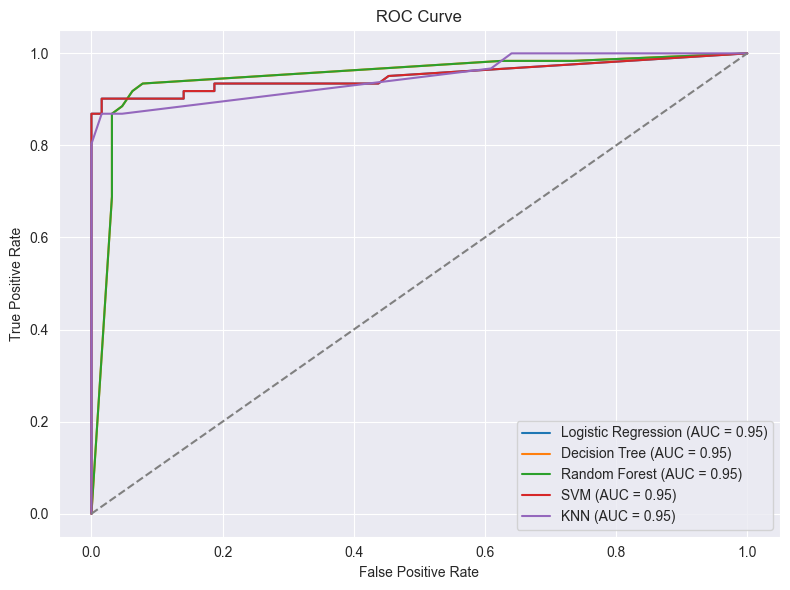

In [26]:
# Compute evaluation metrics
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{name} Model Evaluation:")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    auc = roc_auc_score(y_true, y_prob)
    print(f"AUC: {auc:.4f}")
    return auc

auc_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
auc_dt = evaluate_model("Decision Tree", y_test, y_pred_dt, y_prob_dt)
auc_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
auc_svm = evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm)
auc_knn = evaluate_model("KNN", y_test, y_pred_knn, y_prob_knn)


# Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, X, y, title="", cv=None, scoring='accuracy'):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label='Training score')
    # plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)

    plt.plot(train_sizes, val_mean, 'o-', label='Cross-validation score')
    # plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)

    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid(True)



In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Example classifiers and matching training data
classifiers = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "KNN": knn_model
}

# Corresponding training data for each model
model_train_data = {
    "Logistic Regression": X_train_scaled,
    "Decision Tree": X_train_scaled,
    "Random Forest": X_train_selected,
    "SVM": X_train_scaled,
    "KNN": X_train_scaled
}



Plotting learning curves for all models...


/Users/matthewng/PycharmProjects/BracesImagingClassification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/BracesImagingClassification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/BracesImagingClassification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/BracesImagingClassification/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/matthewng/PycharmProjects/BracesImagingClassification/.venv/lib/pytho

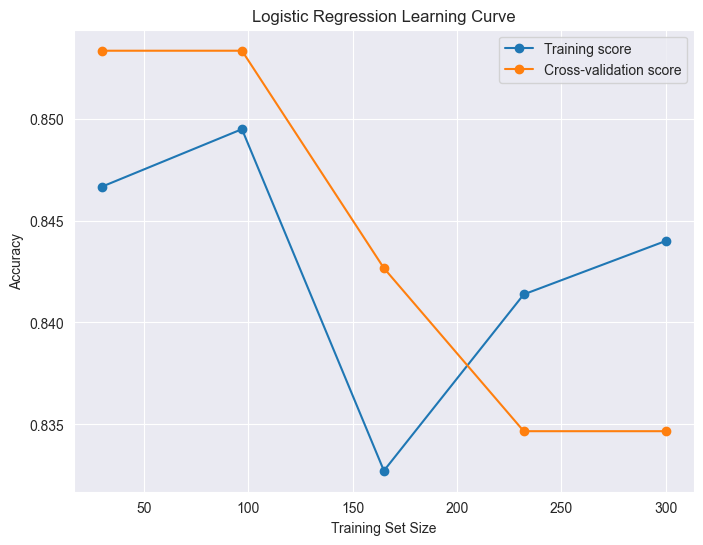

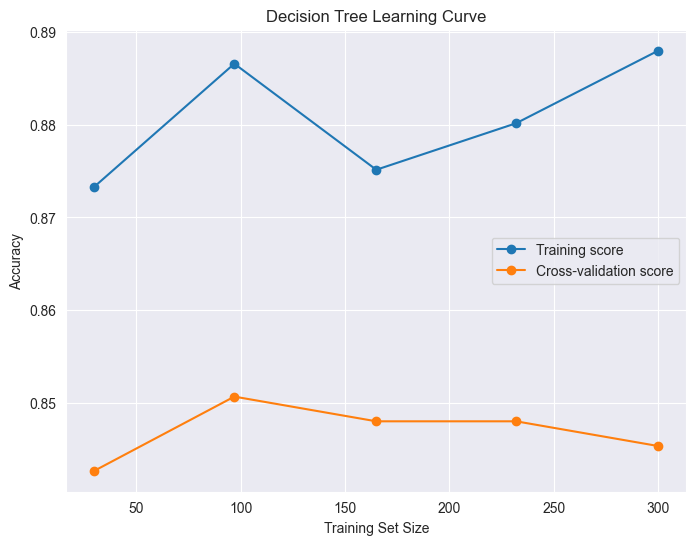

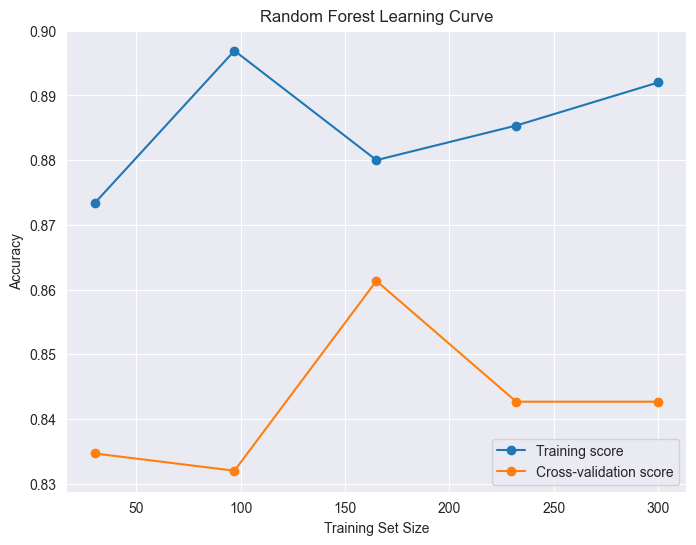

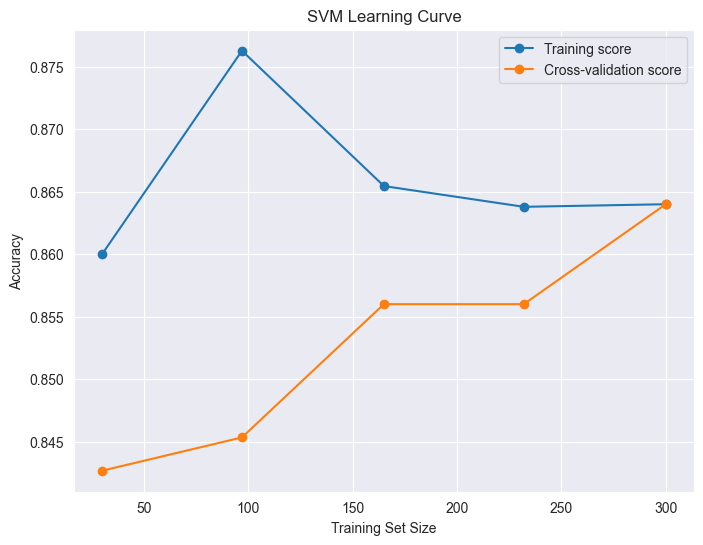

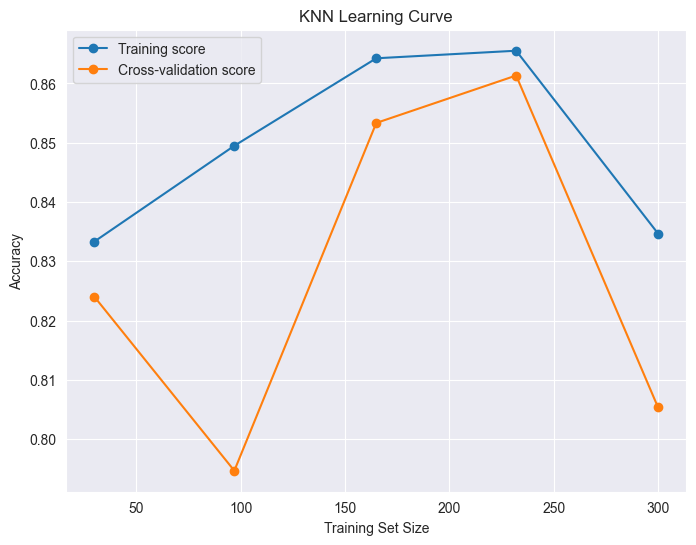

In [44]:
print("Plotting learning curves for all models...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in classifiers.items():
    X_model_train = model_train_data[name]  # Get the right X_train for each model

    plt.figure(figsize=(8, 6))
    plot_learning_curve(model, X_model_train, y_train, title=f"{name} Learning Curve", cv=cv)
    plt.show()



In [85]:
# %% [code]
print("\nBuilding an ensemble of top models (Logistic Regression, Random Forest, SVM)...")

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.ensemble import VotingClassifier

log_clf = LogisticRegression(max_iter=1000)
dt_clf = DecisionTreeClassifier(max_depth=None, min_samples_split=10, min_samples_leaf=4, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
svm_clf = SVC(kernel = 'rbf', C = 100, class_weight='balanced', gamma = 0.1, random_state=42, probability=True)
knn_clf = KNeighborsClassifier(metric= 'euclidean', n_neighbors=7, weights= 'uniform')# Needed for soft voting

# We'll combine three top-performing models based on your earlier results:
voting_clf = VotingClassifier(
    estimators=[
    #    ('lr', log_clf),
        ('dt', dt_clf),
    #    ('rf', rf_clf),
        ('svm', svm_clf),
        ('knn', knn_clf)
                ],
    voting='soft',  # or 'hard'
  weights=[1, 1,1]
)
 # 'soft' averages predicted probabilities

voting_clf.fit(X_train_scaled, y_train)
y_pred_ensemble_tuned = voting_clf.predict(X_test_scaled)

# Calculate evaluation metrics
acc = accuracy_score(y_test, y_pred_ensemble_tuned)
prec = precision_score(y_test, y_pred_ensemble_tuned)
rec = recall_score(y_test, y_pred_ensemble_tuned)
f1 = f1_score(y_test, y_pred_ensemble_tuned)

print("Ensemble (Tuned Models) Evaluation Metrics:")
print(f"Accuracy: {acc:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble_tuned))


Building an ensemble of top models (Logistic Regression, Random Forest, SVM)...
Ensemble (Tuned Models) Evaluation Metrics:
Accuracy: 0.91
Precision: 0.95
Recall: 0.87
F1 Score: 0.91

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.92        64
           1       0.95      0.87      0.91        61

    accuracy                           0.91       125
   macro avg       0.92      0.91      0.91       125
weighted avg       0.91      0.91      0.91       125



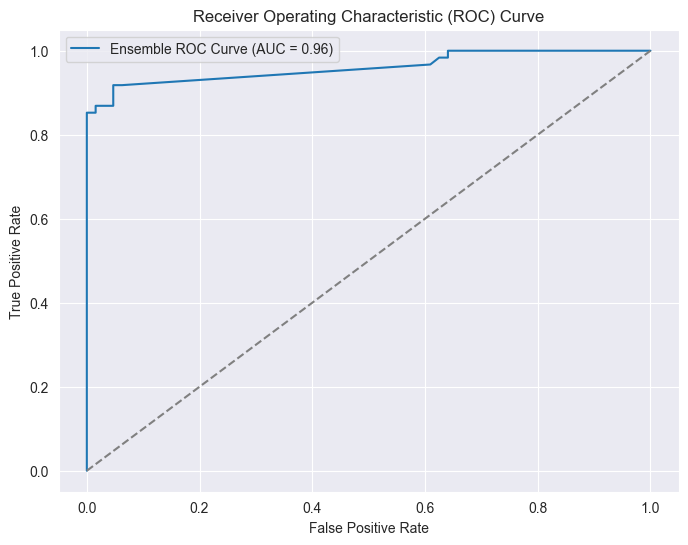

In [86]:
y_proba_ensemble = voting_clf.predict_proba(X_test_scaled)[:, 1]  # Probability for class 1

fpr, tpr, thresholds = roc_curve(y_test, y_proba_ensemble)
auc_score = roc_auc_score(y_test, y_proba_ensemble)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Ensemble ROC Curve (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.grid(True)
plt.show()


Plotting Ensemble Learning Curve with Custom Colors...


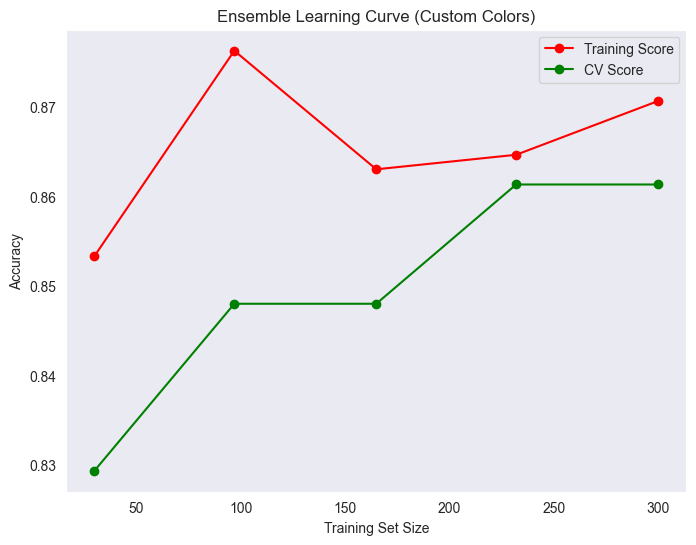

In [84]:
# %% [code]
print("Plotting Ensemble Learning Curve with Custom Colors...")

from sklearn.model_selection import learning_curve, StratifiedKFold

# Ensure ensemble_tuned is defined and trained in previous cells
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, val_scores = learning_curve(
    voting_clf, X_train_scaled, y_train, cv=cv, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5), shuffle=True, random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color='red', label="Training Score")
plt.plot(train_sizes, val_mean, 'o-', color='green', label="CV Score")
plt.title("Ensemble Learning Curve (Custom Colors)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()


In [81]:
import pandas as pd

# Count how many 0s and 1s are in the labels
label_counts = pd.Series(y).value_counts()
print("Label counts:\n", label_counts)



Label counts:
 1    250
0    250
Name: count, dtype: int64
